In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
null_columns_a = ["life_expectancy", "adult_mortality", "bmi", "polio", "diphtheria", "thinness_1_19_years", "thinness_5_9_years"]
drop_columns = [col for col in null_columns_a if col]
null_columns_b = ["alcohol", "hepatitis_b", "total_expenditure", "gdp", "population", "schooling", "income_composition_of_resources"]
imp_cols = [col for col in null_columns_b if col]
imp_mean_col = ["alcohol", "total_expenditure", "gdp", "population", "income_composition_of_resources"]
imp_median_col = ["hepatitis_b", "schooling"]


In [8]:
data = (
    pd.read_csv("life_expectancy_data.csv")
    .rename(columns= lambda col: col.strip().lower().replace(" ", "_").replace("-", "_"))
    .dropna(subset = drop_columns, how = "any")
)


In [6]:
missing_data = data.isnull().sum()
total_obv = data.shape[0]
print(f"Total Sum of Missing Data: {missing_data}")
print(f"Total Number of Observations/Rows:{total_obv}")

Total Sum of Missing Data: country                              0
year                                 0
status                               0
life_expectancy                      0
adult_mortality                      0
infant_deaths                        0
alcohol                            175
percentage_expenditure               0
hepatitis_b                        525
measles                              0
bmi                                  0
under_five_deaths                    0
polio                                0
total_expenditure                  212
diphtheria                           0
hiv/aids                             0
gdp                                435
population                         644
thinness_1_19_years                  0
thinness_5_9_years                   0
income_composition_of_resources    160
schooling                          160
dtype: int64
Total Number of Observations/Rows:2888


In [9]:
missing_percent = missing_data / total_obv * 100
missing_percent

country                             0.000000
year                                0.000000
status                              0.000000
life_expectancy                     0.000000
adult_mortality                     0.000000
infant_deaths                       0.000000
alcohol                             6.059557
percentage_expenditure              0.000000
hepatitis_b                        18.178670
measles                             0.000000
bmi                                 0.000000
under_five_deaths                   0.000000
polio                               0.000000
total_expenditure                   7.340720
diphtheria                          0.000000
hiv/aids                            0.000000
gdp                                15.062327
population                         22.299169
thinness_1_19_years                 0.000000
thinness_5_9_years                  0.000000
income_composition_of_resources     5.540166
schooling                           5.540166
dtype: flo

In [10]:
data.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
count,2888.000000,2888.000000,2888.000000,2888.000000,2713.000000,2888.000000,2363.000000,2888.000000,2888.000000,2888.000000,2888.000000,2676.000000,2888.000000,2888.000000,2453.000000,2.244000e+03,2888.000000,2888.000000,2728.000000,2728.000000
mean,2007.515235,69.349377,163.357341,30.314751,4.643830,749.475611,81.022006,2442.514543,38.221087,41.985803,82.672091,5.931626,82.437673,1.749792,7576.831245,1.283534e+07,4.850589,4.881337,0.632543,12.116312
std,4.606938,9.495441,124.018934,118.891670,4.053529,2003.090073,24.976423,11561.322467,19.962630,161.743345,23.333655,2.482684,23.648907,5.116551,14356.369723,6.155374e+07,4.421403,4.510414,0.206210,3.197199
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.475000,73.000000,0.000000,0.930000,5.049462,77.000000,0.000000,19.300000,0.000000,78.000000,4.270000,78.000000,0.100000,464.184650,1.939068e+05,1.600000,1.500000,0.500000,10.200000
50%,2008.000000,72.200000,143.000000,3.000000,3.810000,67.687008,92.000000,17.000000,43.250000,4.000000,93.000000,5.750000,93.000000,0.100000,1812.288374,1.383743e+06,3.350000,3.400000,0.679500,12.400000
75%,2012.000000,75.800000,225.000000,21.000000,7.800000,454.422430,97.000000,352.250000,56.100000,26.000000,97.000000,7.470000,97.000000,0.800000,6256.559260,7.399592e+06,7.200000,7.200000,0.781000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


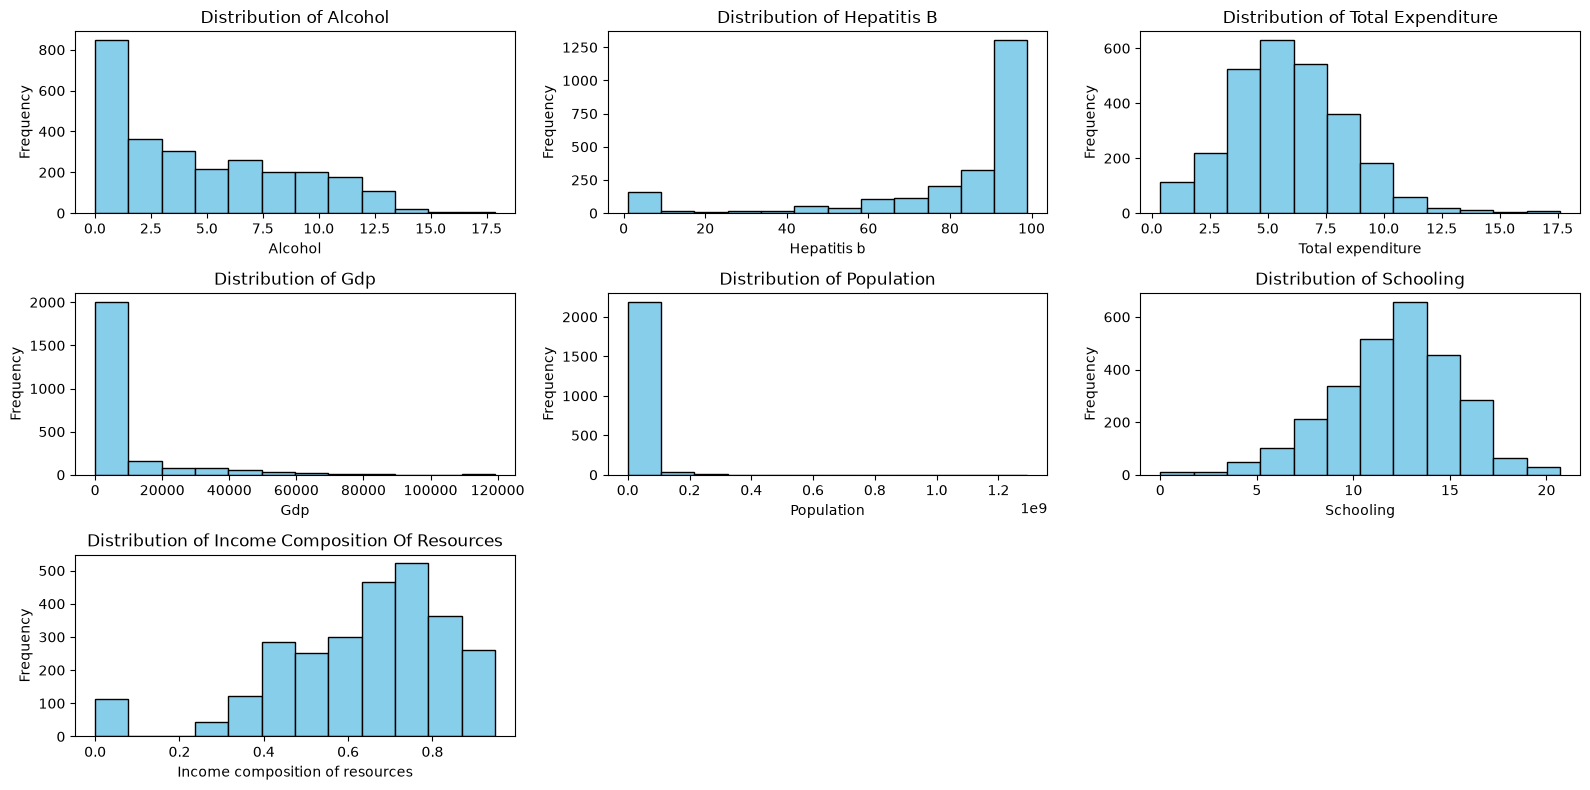

In [11]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (16, 8))
axes = axes.flatten()
for i, col in enumerate(imp_cols):
    axes[i].hist(data[col], bins = 12
    , color = "skyblue", edgecolor = "black")
    axes[i].set_title(f"Distribution of {col.capitalize().replace("_", " ").title()}")
    axes[i].set_xlabel(col.capitalize().replace("_", " "))
    axes[i].set_ylabel("Frequency")
for j in range(len(imp_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()    

In [12]:
for col in imp_mean_col:
    mean_val = data[col].mean()
    data[col] = data[col].fillna(mean_val)  

for col in imp_median_col:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val) 

In [13]:
data.info()

<class 'pandas.DataFrame'>
Index: 2888 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2888 non-null   str    
 1   year                             2888 non-null   int64  
 2   status                           2888 non-null   str    
 3   life_expectancy                  2888 non-null   float64
 4   adult_mortality                  2888 non-null   float64
 5   infant_deaths                    2888 non-null   int64  
 6   alcohol                          2888 non-null   float64
 7   percentage_expenditure           2888 non-null   float64
 8   hepatitis_b                      2888 non-null   float64
 9   measles                          2888 non-null   int64  
 10  bmi                              2888 non-null   float64
 11  under_five_deaths                2888 non-null   int64  
 12  polio                            288

In [27]:
corr_matrix_cols = (
    data.select_dtypes("number").corr()
)
corr_mask = np.triu(np.ones_like(corr_matrix_cols, dtype = bool))
masked_corr_matrix = corr_matrix_cols.mask(corr_mask)

cleaned_corr_matrix = (
    masked_corr_matrix.unstack()
    .dropna()
    .reset_index()
)
cleaned_corr_matrix.columns = ["Metric 1", "Metric 2", "Correlation"]
cleaned_corr_matrix["Abs_Corr"] = cleaned_corr_matrix["Correlation"].abs()
cleaned_corr_matrix = cleaned_corr_matrix.sort_values(by = "Abs_Corr", ascending = False).drop(columns = ["Abs_Corr"]).reset_index(drop = True)
cleaned_corr_matrix

,Metric 1,Metric 2,Correlation
0,infant_deaths,under_five_deaths,0.996635
1,thinness_1_19_years,thinness_5_9_years,0.938803
2,percentage_expenditure,gdp,0.887969
3,income_composition_of_resources,schooling,0.787395
4,life_expectancy,schooling,0.724434
...,...,...,...
185,life_expectancy,population,-0.020842
186,year,population,0.014036
187,adult_mortality,population,-0.011809
188,population,income_composition_of_resources,-0.011185
